<a href="https://colab.research.google.com/github/sanrokurintaro/DICE/blob/main/DICE2013R_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DICE-2013R モデル シミュレーション

**Dynamic Integrated model of Climate and the Economy (DICE) 2013R版**  
William Nordhaus (Yale University) 著  
参考文献: *DICE 2013R: Introduction and User's Manual* (2013)

このノートブックは以下を統合・再現しています：
- PDFマニュアルに記載のDICE-2013R方程式体系
- GitHubリポジトリ `moptimization/pythondice2013implementation` のPython移植版

---

## モデル概要

DICEモデルは「気候変動の経済学」を分析する統合評価モデル(IAM)です。

```
経済活動 → CO₂排出 → 大気濃度上昇 → 放射強制力 → 気温上昇 → 経済被害
     ↑____________________________________________排出削減(政策)___|  
```

**シミュレーション期間**: 2010年〜2300年（5年ごと60期）  
**制御変数**: 排出削減率 μ(t)  
**目的**: 消費の割引効用総和（社会厚生関数）の最大化

---

In [1]:
# ============================================================
# セル1: 必要パッケージのインストールと読み込み
# ============================================================
# Google Colabには標準でnumpy/scipy/matplotlib等が入っているが
# 念のため確認・アップデート

# --- 標準ライブラリのインポート ---
import numpy as np          # 数値計算（配列演算）
import pandas as pd         # データフレーム（表形式データの管理）
import matplotlib.pyplot as plt   # グラフ描画
import matplotlib.ticker as mticker
from scipy.optimize import minimize  # 非線形最適化ソルバー（SLSQPを使用）
import warnings

warnings.filterwarnings('ignore')  # 収束警告を非表示にする

# 日本語フォント設定（Colab環境）
!pip install japanize-matplotlib -q
import japanize_matplotlib

print("✅ パッケージ読み込み完了")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 29.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ パッケージ読み込み完了


In [2]:
# ============================================================
# セル2: DICE-2013Rモデルのパラメータ定義
# ============================================================
# 出典: PDFマニュアル Appendix B §D「2013R version of DICE model」
#       GAMSコード (DICE2013R_100413_vanilla.gms)
#       GitHub: moptimization/pythondice2013implementation/diceParameters.csv
# ============================================================

# ----- 時間設定 -----
T = 60          # シミュレーション期数（1期 = 5年, 2010-2300年）
tstep = 5       # 1期あたりの年数 [年/期]
# 期インデックス: t=1 → 2015年, t=2 → 2020年, ..., t=60 → 2310年
# ※ GAMSコードでは期1が2010年基準（初期値設定用）

# ----- 選好パラメータ (Preferences) -----
# マニュアル §III.A 「社会厚生関数と目的関数」
elasmu = 1.45   # 消費の限界効用弾力性 α (elasticity of marginal utility)
                # → 世代間不平等回避度を表す。高いほど将来世代に配慮
prstp  = 0.015  # 純粋時間選好率 ρ [年率] (pure rate of social time preference)
                # → 現在の消費を将来よりどれだけ重視するか（世代割引率）

# ----- 人口・技術パラメータ (Population and Technology) -----
# マニュアル §III.B 「経済変数」
gama    = 0.300   # 生産関数における資本の産出弾力性 γ (Cobb-Douglas係数)
pop0    = 6838    # 2010年の世界人口 [100万人] → 68.38億人
popadj  = 0.134   # 人口成長率の調整係数（2050年国連予測に合わせてキャリブレーション）
popasym = 10500   # 人口の漸近値（上限）[100万人] → 105億人（2100年頃に収束）
dk      = 0.100   # 資本の減価償却率 δK [年率] (depreciation rate on capital)
q0      = 63.69   # 2010年の世界総生産 [兆ドル（2005年価格）] (gross world product)
k0      = 135.0   # 2010年の資本ストック [兆ドル（2005年価格）]
a0      = 3.80    # 2010年の全要素生産性(TFP)の初期水準 A(2010)
ga0     = 0.079   # TFP成長率の初期値 gA(2015) [5年あたり]
dela    = 0.006   # TFP成長率の低下速度 δA [5年あたり]

# ----- 排出パラメータ (Emissions) -----
# マニュアル §III.B 「式(10): CO₂排出量方程式」
gsigma1 = -0.01   # 炭素強度(σ)の初期成長率 gσ(2015) [年率]
                  # → 負の値 = 技術進歩による脱炭素化を表す
dsig    = -0.001  # 炭素強度成長率の変化速度 δσ [5年あたり]
eland0  = 3.3     # 2010年の土地利用変化によるCO₂排出量 [GtCO₂/年]
                  # ELand(t): 森林伐採などによる排出（外生変数）
deland  = 0.2     # 土地利用排出の減少率 [5年あたり]
e0      = 33.61   # 2010年の産業由来CO₂排出量 [GtCO₂/年]
miu0    = 0.039   # 2010年の排出削減率の初期値（既存政策に相当）

# ----- 炭素循環 初期濃度 (Carbon Cycle - Initial Conditions) -----
# マニュアル §III.C 「式(12)-(15): 3層炭素循環モデル」
mat0  = 830.4    # 2010年の大気中炭素濃度 [GtC from 1750]
                 # MAT: Mass in ATmosphere
mu0   = 1527.0   # 2010年の上層海洋+生物圏の炭素濃度 [GtC from 1750]
                 # MU: Mass in Upper ocean
ml0   = 10010.0  # 2010年の深海の炭素濃度 [GtC from 1750]
                 # ML: Mass in Lower ocean

# ----- 炭素循環 均衡濃度 -----
mateq = 588.0    # 大気の均衡炭素濃度 [GtC] (産業革命前の水準に対応)
mueq  = 1350.0   # 上層海洋の均衡炭素濃度 [GtC]
mleq  = 10000.0  # 深海の均衡炭素濃度 [GtC]

# ----- 炭素循環 移流パラメータ -----
# マニュアル §III.C 「式(13)-(15): φ_{ij}は炭素の移動係数」
b12 = 0.088     # 大気→上層海洋へのフロー係数
b23 = 0.00250   # 上層海洋→深海へのフロー係数
# 以下は均衡条件から導出される（GitHubコードと同一ロジック）
b11 = 1 - b12                   # 大気の自己保持係数
b21 = b12 * mateq / mueq        # 上層海洋→大気へのフロー係数
b22 = 1 - b21 - b23             # 上層海洋の自己保持係数
b32 = b23 * mueq / mleq         # 深海→上層海洋へのフロー係数
b33 = 1 - b32                   # 深海の自己保持係数

# ----- 気候モデルパラメータ (Climate Model) -----
# マニュアル §III.C 「式(16)-(18): 放射強制力と気温方程式」
t2xco2  = 2.9   # 気候感度 [°C/CO₂倍増] (equilibrium temperature sensitivity)
                # → CO₂が2倍になったときの均衡気温上昇幅
fex0    = 0.25  # 2010年のCO₂以外のGHGによる放射強制力 [W/m²]
fex1    = 0.70  # 2100年のCO₂以外のGHGによる放射強制力 [W/m²]
tocean0 = 0.0068 # 2010年の深海温度変化 [°C from 1900]
tatm0   = 0.80  # 2010年の大気温度変化 [°C from 1900]
c1      = 0.098 # 気温方程式の係数（上層の熱慣性）
                # φ₁: 拡散パラメータ（垂直方向の熱拡散率に相当）
c3      = 0.088 # 大気→上層海洋への熱移動係数
c4      = 0.025 # 深海の熱応答係数
fco22x  = 3.8   # CO₂倍増時の放射強制力 [W/m²] (IPCC標準値)

# ----- 被害関数パラメータ (Climate Damage) -----
# マニュアル §III.B 「式(5): 気候被害関数」
# DAMFRAC(t) = a1*TATM(t) + a2*TATM(t)^a3
a1 = 0.0        # 被害関数の線形項係数（2013R版では0: 二次関数型のみ）
a2 = 0.00267    # 被害関数の二次項係数（Tol(2009)の推計に基づく）
a3 = 2.00       # 被害関数の指数（温度上昇の非線形性）

# ----- 削減コストパラメータ (Abatement Cost) -----
# マニュアル §III.B 「式(6): 削減コスト関数 Λ(t) = θ₁(t)·μ(t)^θ₂」
expcost2 = 2.8   # 削減コスト関数の指数 θ₂（限界費用の凸性を表す）
                 # → 削減率が高いほど急速にコストが増加
pback    = 344   # 2010年のバックストップ技術コスト [2005$/tCO₂]
                 # バックストップ技術 = 100%の削減を可能にする代替技術
gback    = 0.025 # バックストップコストの低下速度 [5年あたり]

# ----- 参加・政策パラメータ -----
limmiu        = 1.2  # 排出削減率の上限（2150年以降, 100%超えはネガティブエミッション）
tnopol        = 45   # 政策前の期数（ベースラインシナリオで排出削減なし）
cprice0       = 1.0  # 2010年のベース炭素価格 [2005$/tCO₂]
gcprice       = 0.02 # ベース炭素価格の年間成長率
periodfullpart= 21   # 全世界参加が実現する期（~2100年)
partfract2010 = 1.0  # 2010年の排出管理対象割合
partfractfull = 1.0  # 全参加時の排出管理対象割合

# ----- 化石燃料資源制約 -----
fosslim = 6000   # 化石燃料の累積採掘上限 [GtC]

# ----- スケーリング係数（数値計算の安定化用, 本質的な計算に不要）-----
scale1 = 0.016408662   # 効用関数の乗法的スケーリング係数
scale2 = -3855.106895  # 効用関数の加法的スケーリング係数

print("✅ パラメータ定義完了")
print(f"   シミュレーション期間: {T}期 ({T*tstep}年間 = 2010〜{2010+T*tstep}年)")

✅ パラメータ定義完了
   シミュレーション期間: 60期 (300年間 = 2010〜2310年)


In [3]:
# ============================================================
# セル3: 外生変数の計算（時系列パラメータの生成）
# ============================================================
# GAMSコードの「Further definitions of parameters」セクションに対応
# GitHubの各 get*() 関数に対応
# ============================================================

t_idx = np.arange(1, T+1)   # 期インデックス配列 [1, 2, ..., 60]

# --- (1) 炭素強度の初期値 ---
# sig0 = e0 / (q0 * (1 - miu0))
# 炭素強度 σ = 「産出量1単位当たりのCO₂排出量」
# 産出量q0から既存政策分(miu0)を引いた純粋な炭素強度
sig0 = e0 / (q0 * (1 - miu0))

# --- (2) 人口 L(t) ---
# マニュアル §III.B 「ロジスティック型人口成長式」
# L(t+1) = L(t) * (popasym / L(t))^popadj
# → 人口は最終的に popasym(=105億人)に漸近する
L = np.zeros(T+1)            # L[0]は未使用、L[1]〜L[T]を使用
L[1] = pop0                  # 初期値: 2010年の世界人口
for t in range(1, T):
    L[t+1] = L[t] * (popasym / L[t]) ** popadj

# --- (3) TFP（全要素生産性）A(t) ---
# ga(t) = ga0 * exp(-dela * tstep * (t-1))  ← 成長率は指数関数的に低下
# A(t+1) = A(t) / (1 - ga(t))
ga = ga0 * np.exp(-dela * tstep * (t_idx - 1))   # 各期のTFP成長率
al = np.zeros(T+1)
al[1] = a0                   # 初期TFP
for t in range(1, T):
    al[t+1] = al[t] / (1 - ga[t-1])   # t-1はゼロ始まりのインデックスに対応

# --- (4) 炭素強度の成長率 gsig(t) と 炭素強度 sigma(t) ---
# gsig(t+1) = gsig(t) * (1 + dsig)^tstep  ← 脱炭素化ペースの変化
# sigma(t+1) = sigma(t) * exp(gsig(t) * tstep)
# → 技術進歩により炭素強度は時間とともに低下（負の成長率）
gsig = np.zeros(T+1)
gsig[1] = gsigma1            # 初期の炭素強度成長率（年率）
for t in range(1, T):
    gsig[t+1] = gsig[t] * ((1 + dsig) ** tstep)

sigma = np.zeros(T+1)        # sigma: CO₂排出量/GDP比（炭素強度）
sigma[1] = sig0
for t in range(1, T):
    sigma[t+1] = sigma[t] * np.exp(gsig[t] * tstep)

# --- (5) バックストップ技術価格 pbacktime(t) ---
# pbacktime(t) = pback * (1 - gback)^(t-1)
# → バックストップ価格は毎期 gback(=2.5%)低下する（技術進歩）
pbacktime = pback * (1 - gback) ** (t_idx - 1)

# --- (6) バックストップコストの調整済み係数 cost1(t) ---
# cost1(t) = pbacktime(t) * sigma(t) / expcost2 / 1000
# → 削減コスト関数 Λ(t) = YGROSS(t) * cost1(t) * MIU(t)^expcost2 を計算するための係数
cost1 = np.zeros(T+1)
for t in range(1, T+1):
    cost1[t] = pbacktime[t-1] * sigma[t] / expcost2 / 1000.0
    # ※ pbacktimeはゼロ始まり配列なのでt-1で対応

# --- (7) 土地利用変化によるCO₂排出 etree(t) ---
# etree(t) = eland0 * (1 - deland)^(t-1)
# → 森林伐採等による排出は時間とともに減少する（外生トレンド）
etree = eland0 * (1 - deland) ** (t_idx - 1)

# --- (8) 効用の割引因子 rr(t) ---
# rr(t) = 1 / (1 + prstp)^(tstep*(t-1))
# → 世代間の効用に対する割引因子（将来世代の効用を現在価値換算）
rr = 1.0 / ((1 + prstp) ** (tstep * (t_idx - 1)))

# --- (9) CO₂以外のGHGによる外生的放射強制力 forcoth(t) ---
# → メタン・亜酸化窒素・フロン等の寄与（外生的に増加するとして扱う）
forcoth = np.where(
    t_idx < 19,
    fex0 + (1/18.0) * (fex1 - fex0) * (t_idx - 1),  # 2010-2100: 線形補間
    fex1                                               # 2100以降: 一定
)

# --- (10) 気候パラメータ λ（均衡感度に関連するパラメータ）---
# lam = fco22x / t2xco2  （マニュアルでは式(17)の係数に対応）
lam = fco22x / t2xco2

# --- (11) 排出管理対象の割合 partfract(t) ---
# → 世界の排出量のうち、実際に政策の対象となる割合
partfract = np.ones(T+1)
for t in range(1, T+1):
    if t <= periodfullpart:
        partfract[t] = (partfract2010
                        + (partfractfull - partfract2010) * (t - 1) / periodfullpart)
    else:
        partfract[t] = partfractfull

# --- (12) 長期均衡貯蓄率 optlrsav ---
# → モデルの境界条件として、最後の10期は貯蓄率を固定する
optlrsav = (dk + 0.004) / (dk + 0.004 * elasmu + prstp) * gama

# --- (13) ベースケースの炭素価格経路 cpricebase(t) ---
# → 最適化なしのベースラインで使用する外生的な炭素価格
cpricebase = cprice0 * (1 + gcprice) ** (tstep * (t_idx - 1))

# --- 年西暦の配列 ---
years = 2010 + tstep * (t_idx - 1)   # [2010, 2015, 2020, ..., 2305]

print("✅ 外生変数の計算完了")
print(f"   2010年の炭素強度 σ(1) = {sigma[1]:.4f} [kgCO₂/$(2005年価格)]")
print(f"   2010年の人口 L(1)     = {L[1]:.0f} 百万人")
print(f"   2010年のTFP A(1)      = {al[1]:.2f}")
print(f"   長期均衡貯蓄率         = {optlrsav:.4f}")

✅ 外生変数の計算完了
   2010年の炭素強度 σ(1) = 0.5491 [kgCO₂/$(2005年価格)]
   2010年の人口 L(1)     = 6838 百万人
   2010年のTFP A(1)      = 3.80
   長期均衡貯蓄率         = 0.2583


In [4]:
# ============================================================
# セル4: シミュレーション（前向き計算）関数の定義
# ============================================================
# 排出削減率 MIU(t) と 貯蓄率 S(t) を与えると、
# モデル全変数の時系列を計算して返す関数
#
# 計算フロー（各期 t に対して）:
#   YGROSS(t) → [DAMFRAC, ABATECOST] → Y(t) → [C(t), I(t)] → K(t+1)
#   MAT(t+1), MU(t+1), ML(t+1) → FORC(t+1) → TATM(t+1), TOCEAN(t+1)
# ============================================================

def simulate_dice(miu_path, s_path):
    """
    DICEモデルの前向き（逐次）シミュレーション

    引数:
        miu_path (array): 排出削減率 MIU[1..T]（0=削減なし, 1=100%削減）
        s_path   (array): 貯蓄率 S[1..T]（GDPに占める投資の割合）

    戻り値:
        dict: 全変数の時系列を格納した辞書
    """

    # --- 配列の初期化（全てゼロで初期化後、初期条件を設定）---
    MAT    = np.zeros(T+2)   # 大気中炭素濃度 [GtC from 1750]
    MU     = np.zeros(T+2)   # 上層海洋炭素濃度 [GtC from 1750]
    ML     = np.zeros(T+2)   # 深海炭素濃度 [GtC from 1750]
    FORC   = np.zeros(T+1)   # 放射強制力 [W/m²]
    TATM   = np.zeros(T+2)   # 大気温度変化 [°C from 1900]
    TOCEAN = np.zeros(T+2)   # 深海温度変化 [°C from 1900]
    K      = np.zeros(T+2)   # 資本ストック [兆ドル]
    YGROSS = np.zeros(T+1)   # 粗GDP（気候被害・削減費用控除前）[兆ドル/年]
    YNET   = np.zeros(T+1)   # 被害控除後GDP [兆ドル/年]
    Y      = np.zeros(T+1)   # 純GDP（被害・削減費用控除後）[兆ドル/年]
    DAMFRAC= np.zeros(T+1)   # GDPに占める気候被害の割合
    DAMAGES= np.zeros(T+1)   # 気候被害額 [兆ドル/年]
    ABATECOST = np.zeros(T+1)  # CO₂削減費用 [兆ドル/年]
    E      = np.zeros(T+1)   # 総CO₂排出量 [GtCO₂/年]
    EIND   = np.zeros(T+1)   # 産業由来CO₂排出量 [GtCO₂/年]
    C      = np.zeros(T+1)   # 総消費 [兆ドル/年]
    CPC    = np.zeros(T+1)   # 一人当たり消費 [千ドル/年]
    I      = np.zeros(T+1)   # 投資 [兆ドル/年]
    PERIODU= np.zeros(T+1)   # 一期間の効用（各期の瞬間効用）
    CEMUTOTPER = np.zeros(T+1)  # 加重効用（人口×割引因子×効用）
    CCA    = np.zeros(T+2)   # 累積炭素排出量 [GtC]
    CPRICE = np.zeros(T+1)   # 炭素価格 [2005$/tCO₂]
    MCABATE= np.zeros(T+1)   # 削減の限界費用 [2005$/tCO₂]
    RI     = np.zeros(T+1)   # 実質利子率 [年率]

    # --- 初期条件の設定（t=1: 2010年の観測値）---
    MAT[1]    = mat0      # 大気炭素濃度: 830.4 GtC
    MU[1]     = mu0       # 上層海洋: 1527 GtC
    ML[1]     = ml0       # 深海: 10010 GtC
    TATM[1]   = tatm0     # 大気気温上昇: +0.80°C
    TOCEAN[1] = tocean0   # 深海気温上昇: +0.0068°C
    K[1]      = k0        # 資本ストック: 135兆ドル
    CCA[1]    = 90.0      # 2010年時点の累積炭素排出量 [GtC]

    # --- メインループ: 各期 t=1,...,T を順番に計算 ---
    for t in range(1, T+1):

        # == 経済セクター ==

        # 粗GDP: コブ=ダグラス生産関数
        # YGROSS(t) = A(t) * [L(t)/1000]^(1-γ) * K(t)^γ
        # マニュアル 式(4)
        YGROSS[t] = al[t] * (L[t] / 1000.0) ** (1 - gama) * K[t] ** gama

        # 放射強制力: CO₂倍増に伴う熱放射の変化
        # FORC(t) = fco22x * log₂(MAT(t)/588) + forcoth(t)
        # マニュアル 式(16)
        FORC[t] = fco22x * (np.log(MAT[t] / 588.0) / np.log(2)) + forcoth[t-1]
        # ※ forcothはゼロ始まり配列なのでt-1

        # 気候被害の割合: 温度の二次関数
        # DAMFRAC(t) = a1*TATM(t) + a2*TATM(t)^a3
        # マニュアル 式(5)  ※a1=0なので実質的に二次項のみ
        DAMFRAC[t] = a1 * TATM[t] + a2 * TATM[t] ** a3

        # 気候被害額（絶対額）
        DAMAGES[t] = YGROSS[t] * DAMFRAC[t]

        # 削減費用: コスト関数
        # ABATECOST(t) = YGROSS(t) * cost1(t) * MIU(t)^expcost2 * partfract^(1-expcost2)
        # マニュアル 式(6)
        ABATECOST[t] = (YGROSS[t] * cost1[t]
                        * miu_path[t] ** expcost2
                        * partfract[t] ** (1 - expcost2))

        # 被害控除後GDP
        YNET[t] = YGROSS[t] * (1 - DAMFRAC[t])

        # 純GDP（被害＋削減費用を控除）
        # Y(t) = YNET(t) - ABATECOST(t)  マニュアル 式(4)全体
        Y[t] = YNET[t] - ABATECOST[t]

        # 投資・消費の分割
        # I(t) = S(t) * Y(t)     マニュアル 式(7)
        # C(t) = Y(t) - I(t)
        I[t] = s_path[t] * Y[t]
        C[t] = max(Y[t] - I[t], 2.0)    # 下限: 2兆ドル/年

        # 一人当たり消費 [千ドル/年]
        # CPC(t) = 1000 * C(t) / L(t)  マニュアル 式(8)
        CPC[t] = 1000.0 * C[t] / L[t]

        # 瞬間効用関数（CRRA型: 一定相対的危険回避度）
        # PERIODU(t) = [(CPC(t))^(1-α) - 1] / (1-α) - 1
        # マニュアル 式(2)  α=elasmu
        PERIODU[t] = ((CPC[t]) ** (1 - elasmu) - 1) / (1 - elasmu) - 1

        # 加重効用: 人口×割引因子×効用
        # CEMUTOTPER(t) = PERIODU(t) * L(t) * R(t)  マニュアル 式(1)
        CEMUTOTPER[t] = PERIODU[t] * L[t] * rr[t-1]   # rr はゼロ始まり

        # == 炭素・排出セクター ==

        # 産業由来CO₂排出量
        # EIND(t) = σ(t) * [1 - MIU(t)] * YGROSS(t)  マニュアル 式(10)
        EIND[t] = sigma[t] * (1 - miu_path[t]) * YGROSS[t]

        # 総CO₂排出量（産業 + 土地利用変化）
        # E(t) = EIND(t) + ELand(t)  マニュアル 式(12)
        E[t] = EIND[t] + etree[t-1]    # etreeはゼロ始まり

        # 累積炭素排出量 [GtC]
        # CCA(t+1) = CCA(t) + EIND(t) * tstep / 3.666
        # ※ GtCO₂ → GtC 換算: 3.666 = CO₂/C の分子量比 (44/12)
        if t < T+1:
            CCA[t+1] = min(CCA[t] + EIND[t] * tstep / 3.666, fosslim)

        # 炭素価格（最適化時は限界削減費用に等しい）
        # CPRICE(t) = pbacktime(t) * [MIU(t)/partfract(t)]^(expcost2-1)
        CPRICE[t] = pbacktime[t-1] * (miu_path[t] / partfract[t]) ** (expcost2 - 1)

        # 削減の限界費用
        MCABATE[t] = pbacktime[t-1] * miu_path[t] ** (expcost2 - 1)

        # == 次期の状態変数を更新 ==

        if t < T+1:
            # 資本ストック: 永久インベントリ法
            # K(t+1) = (1-δK)^tstep * K(t) + tstep * I(t)  マニュアル 式(9)
            K[t+1] = max((1 - dk) ** tstep * K[t] + tstep * I[t], 1.0)  # 下限: 1兆ドル

            # 炭素循環: 3層モデル  マニュアル 式(13)-(15)
            # MAT(t+1) = b11*MAT(t) + b21*MU(t) + E(t)*tstep/3.666
            MAT[t+1] = max(
                MAT[t] * b11 + MU[t] * b21 + E[t] * tstep / 3.666,
                10.0  # 大気濃度の下限
            )
            # MU(t+1) = b12*MAT(t) + b22*MU(t) + b32*ML(t)
            MU[t+1] = max(
                MAT[t] * b12 + MU[t] * b22 + ML[t] * b32,
                100.0  # 上層海洋濃度の下限
            )
            # ML(t+1) = b23*MU(t) + b33*ML(t)
            ML[t+1] = max(
                MU[t] * b23 + ML[t] * b33,
                1000.0  # 深海濃度の下限
            )

            # 気温変化: エネルギー収支モデル  マニュアル 式(17)-(18)
            # TATM(t+1) = TATM(t) + c1*[FORC(t) - (fco22x/t2xco2)*TATM(t) - c3*(TATM(t)-TOCEAN(t))]
            TATM[t+1] = min(max(
                TATM[t] + c1 * (
                    FORC[t]
                    - lam * TATM[t]              # 均衡に向けた復元力
                    - c3 * (TATM[t] - TOCEAN[t]) # 大気→深海への熱移動
                ),
                0.0), 40.0)   # 上限: 40°C

            # TOCEAN(t+1) = TOCEAN(t) + c4*(TATM(t) - TOCEAN(t))
            TOCEAN[t+1] = min(max(
                TOCEAN[t] + c4 * (TATM[t] - TOCEAN[t]),
                -1.0), 20.0)  # 範囲: -1〜20°C

    # 実質利子率の計算
    # RI(t) = (1+ρ) * (CPC(t)/CPC(t-1))^(α/tstep) - 1  マニュアル 式に相当
    for t in range(2, T+1):
        if CPC[t-1] > 0:
            RI[t] = (1 + prstp) * (CPC[t] / CPC[t-1]) ** (elasmu / tstep) - 1

    # 社会厚生関数（目的関数）
    # W = tstep * scale1 * Σ CEMUTOTPER(t) + scale2  マニュアル 式(1)
    UTILITY = tstep * scale1 * np.sum(CEMUTOTPER[1:T+1]) + scale2

    return {
        'UTILITY': UTILITY,     # 社会厚生（目的関数値）
        'MAT': MAT,             # 大気炭素濃度 [GtC]
        'MU': MU,               # 上層海洋炭素濃度 [GtC]
        'ML': ML,               # 深海炭素濃度 [GtC]
        'FORC': FORC,           # 放射強制力 [W/m²]
        'TATM': TATM,           # 大気気温変化 [°C]
        'TOCEAN': TOCEAN,       # 深海気温変化 [°C]
        'K': K,                 # 資本ストック [兆ドル]
        'YGROSS': YGROSS,       # 粗GDP [兆ドル/年]
        'YNET': YNET,           # 被害控除後GDP [兆ドル/年]
        'Y': Y,                 # 純GDP [兆ドル/年]
        'DAMFRAC': DAMFRAC,     # 気候被害率
        'DAMAGES': DAMAGES,     # 気候被害額 [兆ドル]
        'ABATECOST': ABATECOST, # 削減費用 [兆ドル]
        'E': E,                 # 総CO₂排出量 [GtCO₂/年]
        'EIND': EIND,           # 産業CO₂排出量 [GtCO₂/年]
        'C': C,                 # 消費 [兆ドル]
        'CPC': CPC,             # 一人当たり消費 [千ドル]
        'I': I,                 # 投資 [兆ドル]
        'PERIODU': PERIODU,     # 瞬間効用
        'CEMUTOTPER': CEMUTOTPER, # 加重効用
        'CCA': CCA,             # 累積炭素排出量 [GtC]
        'CPRICE': CPRICE,       # 炭素価格 [$/tCO₂]
        'MCABATE': MCABATE,     # 限界削減費用 [$/tCO₂]
        'RI': RI,               # 実質利子率
        'MIU': miu_path,        # 入力: 排出削減率
        'S': s_path,            # 入力: 貯蓄率
        'L': L,                 # 外生: 人口
        'al': al,               # 外生: TFP
        'sigma': sigma,         # 外生: 炭素強度
    }

print("✅ シミュレーション関数の定義完了")

✅ シミュレーション関数の定義完了


In [5]:
# ============================================================
# セル5: ベースラインシナリオ（政策なし）のシミュレーション
# ============================================================
# マニュアル §IV.A 「ベースラインシナリオ」
# → 2010年時点の既存政策が延長されるシナリオ（追加的な削減措置なし）
# ============================================================

# --- ベースラインのMIU（排出削減率）設定 ---
# ベースラインでは、MIU は炭素価格に基づいて計算される
# cpricebase(t) = cprice0 * (1+gcprice)^(5*(t-1))  で与えられる炭素価格経路
# MIU = (cpricebase / pbacktime)^(1/(expcost2-1)) * partfract  を逆算

miu_base = np.zeros(T+1)    # 排出削減率の初期化
miu_base[1] = miu0          # 2010年: 既存政策相当 (3.9%)

for t in range(2, T+1):
    # ベースライン炭素価格から削減率を逆算
    # CPRICE = pbacktime * (MIU/partfract)^(expcost2-1)
    # → MIU = partfract * (cpricebase/pbacktime)^(1/(expcost2-1))
    ratio = cpricebase[t-1] / pbacktime[t-1]   # 価格比（炭素価格/バックストップ価格）
    miu_base[t] = min(
        partfract[t] * ratio ** (1.0 / (expcost2 - 1)),
        partfract[t] * limmiu  # 上限制約
    )
    if t < 30:               # 2010-2155年: 上限=100%
        miu_base[t] = min(miu_base[t], 1.0)

# --- ベースラインの貯蓄率設定 ---
# 最初は一定の貯蓄率、最後10期は均衡貯蓄率に固定
s_base = np.full(T+1, 0.2596)    # 約26%（均衡に近い水準）
for t in range(T-9, T+1):         # 最後10期
    s_base[t] = optlrsav          # 長期均衡貯蓄率に固定

# --- ベースラインシミュレーション実行 ---
baseline = simulate_dice(miu_base, s_base)

print("✅ ベースラインシミュレーション完了")
print(f"   社会厚生 W = {baseline['UTILITY']:.4f}")
print(f"   2100年の大気気温上昇: {baseline['TATM'][19]:.2f}°C")
print(f"   2200年の大気気温上昇: {baseline['TATM'][39]:.2f}°C")

✅ ベースラインシミュレーション完了
   社会厚生 W = 2671.3074
   2100年の大気気温上昇: 3.72°C
   2200年の大気気温上昇: 6.29°C


In [6]:
# ============================================================
# セル6: 最適シナリオの数値最適化
# ============================================================
# マニュアル §IV.A 「最適シナリオ: 経済厚生を最大化する排出削減経路」
# → MIU(t) と S(t) を同時に最適化
# 最適化手法: SciPy SLSQP（逐次二次計画法）
#              GAMSではIPOPT（内点法）を使用しているが、
#              Colab環境では SLSQP が簡便（インストール不要）
# ============================================================

def objective(x):
    """
    最適化の目的関数（最大化 → 負の符号で最小化として定式化）

    引数 x の構造:
      x[0:T]       → MIU[1..T]: 各期の排出削減率
      x[T:2T]      → S[1..T]: 各期の貯蓄率
    """
    miu = np.zeros(T+1)
    s   = np.zeros(T+1)
    miu[1:T+1] = x[:T]     # 最適化変数から配列を構築
    s[1:T+1]   = x[T:2*T]

    # 最後10期の貯蓄率は均衡値に固定（境界条件）
    for t in range(T-9, T+1):
        s[t] = optlrsav

    result = simulate_dice(miu, s)
    return -result['UTILITY']   # 負符号: 最小化 = 最大化問題に変換

# --- 初期値の設定 ---
x0 = np.concatenate([
    miu_base[1:T+1],      # MIUの初期値: ベースライン
    s_base[1:T+1]         # S の初期値: ベースライン
])

# --- 変数の上下限（ボックス制約）---
bounds = []

# MIU の制約
for t in range(1, T+1):
    if t == 1:
        bounds.append((miu0, miu0))           # t=1: 初期値に固定
    elif t < 30:
        bounds.append((0.0, 1.0))             # t<30: 0〜100%
    else:
        bounds.append((0.0, limmiu * partfract[t]))  # t≥30: 上限=limmiu

# S の制約
for t in range(1, T+1):
    if t > T - 10:
        bounds.append((optlrsav, optlrsav))   # 最後10期: 固定
    else:
        bounds.append((0.1, 0.9))             # 貯蓄率: 10〜90%

print("🔄 最適化を実行中... (数分かかる場合があります)")

# --- 最適化の実行 ---
# method='SLSQP': 制約付き非線形最適化（逐次二次計画法）
# GAMSのIPOPTと比べると精度が若干落ちる可能性があるが、
# 外部ソルバーなしでColab上で動作する
result_opt = minimize(
    objective,
    x0,
    method='SLSQP',
    bounds=bounds,
    options={
        'maxiter': 2000,   # 最大反復回数
        'ftol': 1e-9,      # 収束判定（目的関数の変化量）
        'disp': False      # 途中経過の表示をオフ
    }
)

# --- 最適解の抽出 ---
miu_opt = np.zeros(T+1)
s_opt   = np.zeros(T+1)
miu_opt[1:T+1] = result_opt.x[:T]
s_opt[1:T+1]   = result_opt.x[T:2*T]
for t in range(T-9, T+1):
    s_opt[t] = optlrsav

optimal = simulate_dice(miu_opt, s_opt)

print("✅ 最適化完了")
print(f"   収束ステータス: {result_opt.message}")
print(f"   最大社会厚生 W = {optimal['UTILITY']:.4f}")
print(f"   2100年の気温上昇: {optimal['TATM'][19]:.2f}°C")
print(f"   2015年の最適炭素価格: ${optimal['CPRICE'][1]:.2f}/tCO₂")

🔄 最適化を実行中... (数分かかる場合があります)
✅ 最適化完了
   収束ステータス: Optimization terminated successfully
   最大社会厚生 W = 2691.3145
   2100年の気温上昇: 3.05°C
   2015年の最適炭素価格: $1.00/tCO₂


In [7]:
# ============================================================
# セル7: 2°C制限シナリオ（コペンハーゲン合意相当）
# ============================================================
# マニュアル §IV.A 「気温制限シナリオ」
# → 大気気温を2°C以下に抑える制約のもとで最適化
# ============================================================

TEMP_LIMIT = 2.0    # 気温上昇の上限 [°C above 1900 average]

def objective_2deg(x):
    """目的関数（2°C制限なし、制約として別途扱う）"""
    miu = np.zeros(T+1)
    s   = np.zeros(T+1)
    miu[1:T+1] = x[:T]
    s[1:T+1]   = x[T:2*T]
    for t in range(T-9, T+1):
        s[t] = optlrsav
    result = simulate_dice(miu, s)
    return -result['UTILITY']

def temp_constraint(x):
    """気温制約: 全期において TATM(t) ≤ 2.0°C を満たすこと"""
    miu = np.zeros(T+1)
    s   = np.zeros(T+1)
    miu[1:T+1] = x[:T]
    s[1:T+1]   = x[T:2*T]
    for t in range(T-9, T+1):
        s[t] = optlrsav
    result = simulate_dice(miu, s)
    # 全期において 2°C - TATM(t) ≥ 0 を要求
    return TEMP_LIMIT - max(result['TATM'][1:T+1])

constraints_2deg = [
    {'type': 'ineq', 'fun': temp_constraint}  # 不等式制約（≥ 0）
]

print("🔄 2°C制限シナリオを最適化中...")

# 2°C制限シナリオは初期値を最適解から開始（収束しやすくするため）
x0_2deg = result_opt.x.copy()

result_2deg = minimize(
    objective_2deg,
    x0_2deg,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints_2deg,
    options={'maxiter': 3000, 'ftol': 1e-8, 'disp': False}
)

miu_2deg = np.zeros(T+1)
s_2deg   = np.zeros(T+1)
miu_2deg[1:T+1] = result_2deg.x[:T]
s_2deg[1:T+1]   = result_2deg.x[T:2*T]
for t in range(T-9, T+1):
    s_2deg[t] = optlrsav

tdeg = simulate_dice(miu_2deg, s_2deg)

print("✅ 2°C制限シナリオ完了")
print(f"   最大気温上昇: {max(tdeg['TATM'][1:T+1]):.2f}°C")
print(f"   2015年の炭素価格: ${tdeg['CPRICE'][1]:.2f}/tCO₂")

🔄 2°C制限シナリオを最適化中...
✅ 2°C制限シナリオ完了
   最大気温上昇: 2.00°C
   2015年の炭素価格: $1.00/tCO₂


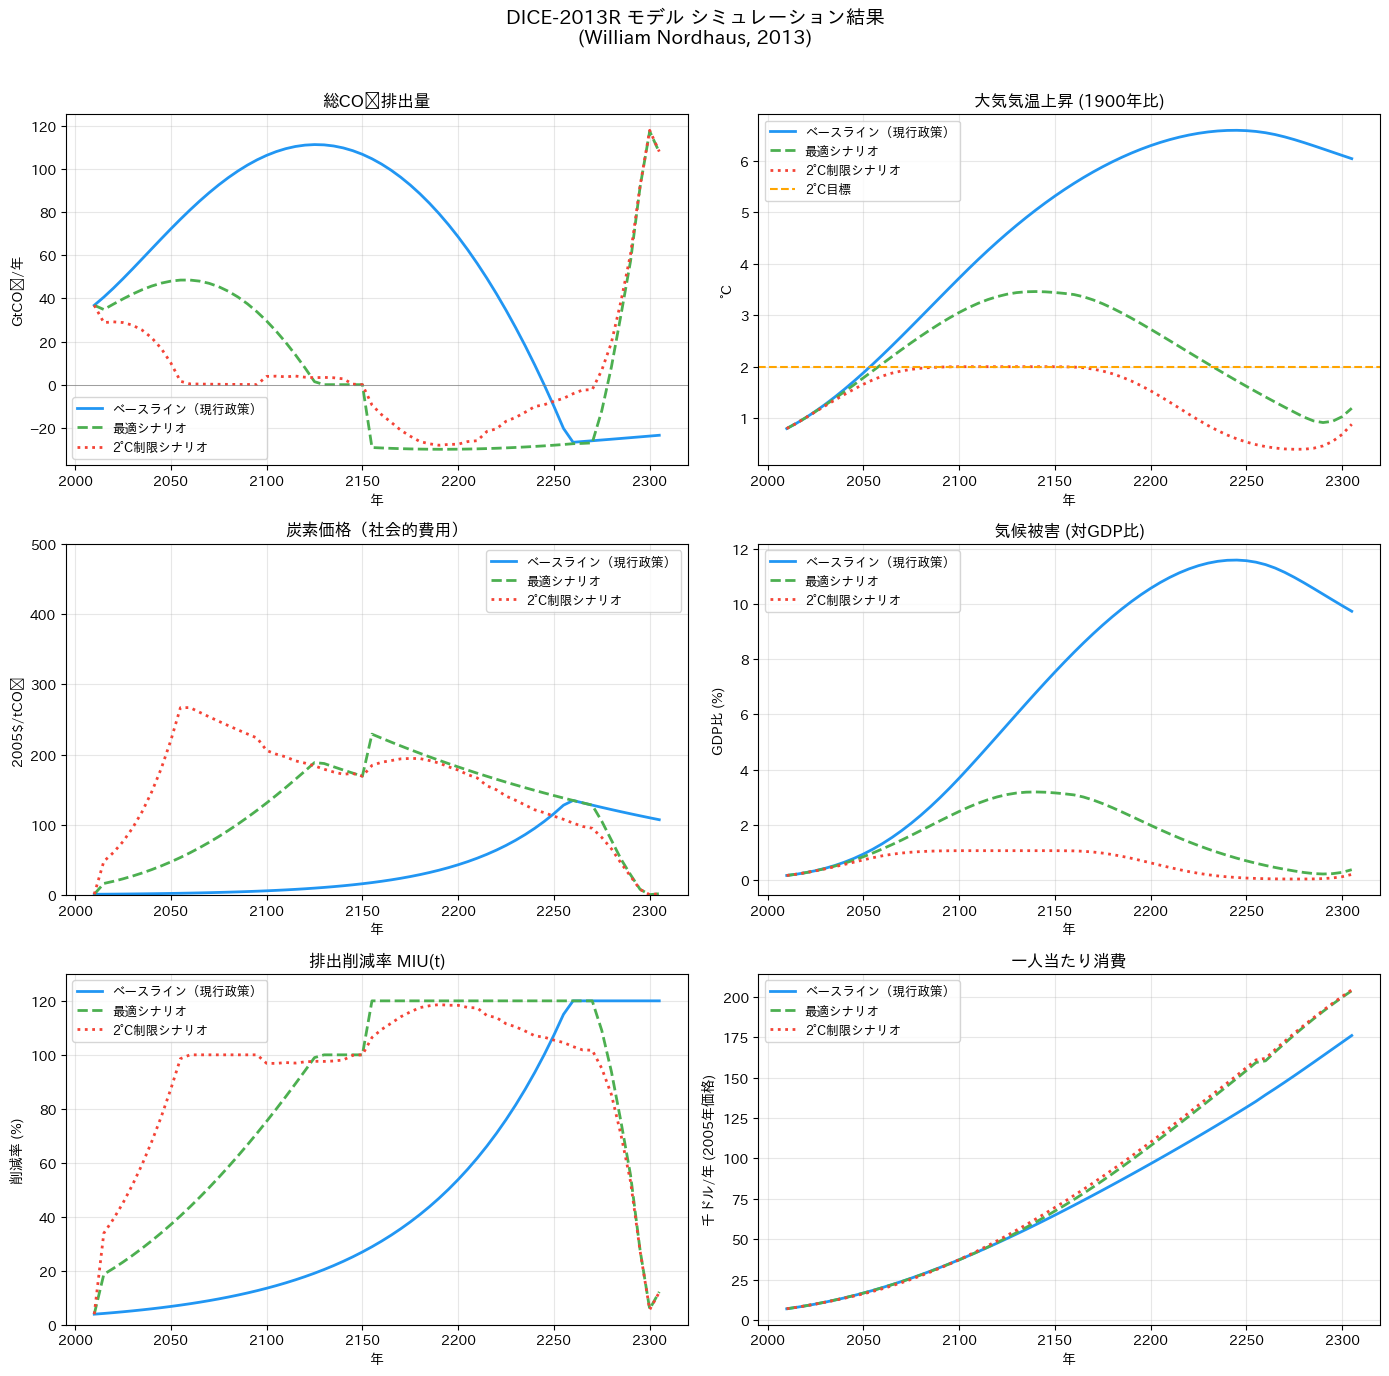

✅ グラフ保存: dice2013r_results.png


In [8]:
# ============================================================
# セル8: 結果のグラフ化（6パネル）
# ============================================================
# マニュアル §IV.B 「主要結果」に対応する図を再現
# ============================================================

# 比較する3シナリオ
scenarios = {
    'ベースライン（現行政策）': baseline,
    '最適シナリオ': optimal,
    '2°C制限シナリオ': tdeg,
}
colors = ['#2196F3', '#4CAF50', '#F44336']   # 青, 緑, 赤
linestyles = ['-', '--', ':']

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle('DICE-2013R モデル シミュレーション結果\n(William Nordhaus, 2013)',
             fontsize=14, fontweight='bold', y=0.98)

yr = years   # 横軸: 西暦年

# --- パネル(1): CO₂排出量 ---
ax = axes[0, 0]
for (name, sc), color, ls in zip(scenarios.items(), colors, linestyles):
    ax.plot(yr, sc['E'][1:T+1], label=name, color=color, linestyle=ls, linewidth=2)
ax.set_title('総CO₂排出量', fontsize=12, fontweight='bold')
ax.set_xlabel('年')
ax.set_ylabel('GtCO₂/年')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', linewidth=0.5)

# --- パネル(2): 大気気温上昇 ---
ax = axes[0, 1]
for (name, sc), color, ls in zip(scenarios.items(), colors, linestyles):
    ax.plot(yr, sc['TATM'][1:T+1], label=name, color=color, linestyle=ls, linewidth=2)
ax.axhline(2.0, color='orange', linewidth=1.5, linestyle='--', label='2°C目標')
ax.set_title('大気気温上昇 (1900年比)', fontsize=12, fontweight='bold')
ax.set_xlabel('年')
ax.set_ylabel('°C')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- パネル(3): 炭素価格（社会的費用）---
ax = axes[1, 0]
for (name, sc), color, ls in zip(scenarios.items(), colors, linestyles):
    ax.plot(yr, sc['CPRICE'][1:T+1], label=name, color=color, linestyle=ls, linewidth=2)
ax.set_title('炭素価格（社会的費用）', fontsize=12, fontweight='bold')
ax.set_xlabel('年')
ax.set_ylabel('2005$/tCO₂')
ax.set_ylim(0, 500)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- パネル(4): 気候被害額 ---
ax = axes[1, 1]
for (name, sc), color, ls in zip(scenarios.items(), colors, linestyles):
    # 被害率（GDPに占める割合）を%で表示
    ax.plot(yr, sc['DAMFRAC'][1:T+1] * 100,
            label=name, color=color, linestyle=ls, linewidth=2)
ax.set_title('気候被害 (対GDP比)', fontsize=12, fontweight='bold')
ax.set_xlabel('年')
ax.set_ylabel('GDP比 (%)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- パネル(5): 排出削減率 ---
ax = axes[2, 0]
for (name, sc), color, ls in zip(scenarios.items(), colors, linestyles):
    ax.plot(yr, sc['MIU'][1:T+1] * 100,
            label=name, color=color, linestyle=ls, linewidth=2)
ax.set_title('排出削減率 MIU(t)', fontsize=12, fontweight='bold')
ax.set_xlabel('年')
ax.set_ylabel('削減率 (%)')
ax.set_ylim(0, 130)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- パネル(6): 一人当たり消費 ---
ax = axes[2, 1]
for (name, sc), color, ls in zip(scenarios.items(), colors, linestyles):
    ax.plot(yr, sc['CPC'][1:T+1], label=name, color=color, linestyle=ls, linewidth=2)
ax.set_title('一人当たり消費', fontsize=12, fontweight='bold')
ax.set_xlabel('年')
ax.set_ylabel('千ドル/年 (2005年価格)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('dice2013r_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ グラフ保存: dice2013r_results.png")

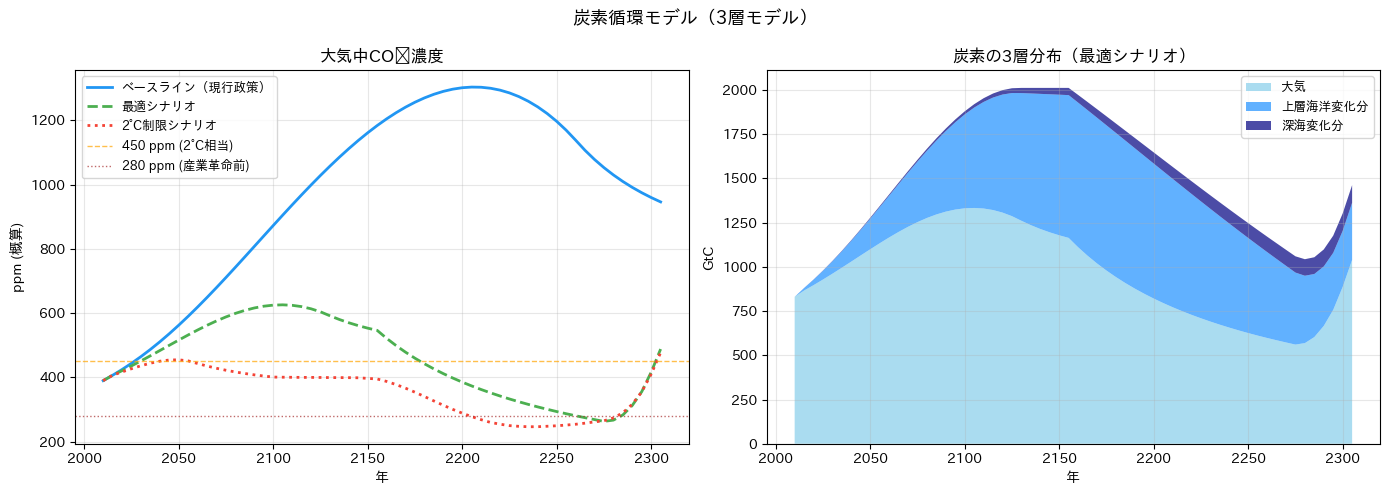

In [9]:
# ============================================================
# セル9: 大気中CO₂濃度と炭素循環の可視化
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('炭素循環モデル（3層モデル）', fontsize=13, fontweight='bold')

# --- 左: 大気炭素濃度 ---
ax = axes[0]
for (name, sc), color, ls in zip(scenarios.items(), colors, linestyles):
    # GtC → ppm 変換 (1 GtC ≈ 0.4697 ppm)
    mat_ppm = sc['MAT'][1:T+1] / 830.4 * 390   # 2010年実測値390ppmを基準に換算
    ax.plot(yr, mat_ppm, label=name, color=color, linestyle=ls, linewidth=2)
ax.axhline(450, color='orange', linewidth=1, linestyle='--', alpha=0.7, label='450 ppm (2°C相当)')
ax.axhline(280, color='brown', linewidth=1, linestyle=':', alpha=0.7, label='280 ppm (産業革命前)')
ax.set_title('大気中CO₂濃度')
ax.set_xlabel('年')
ax.set_ylabel('ppm (概算)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- 右: 3層炭素循環の内訳（最適シナリオ）---
ax = axes[1]
ax.stackplot(yr,
             optimal['MAT'][1:T+1],
             optimal['MU'][1:T+1] - 1527,   # 初期値からの変化量
             optimal['ML'][1:T+1] - 10010,  # 初期値からの変化量
             labels=['大気', '上層海洋変化分', '深海変化分'],
             colors=['#87CEEB', '#1E90FF', '#000080'],
             alpha=0.7)
ax.set_title('炭素の3層分布（最適シナリオ）')
ax.set_xlabel('年')
ax.set_ylabel('GtC')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# セル10: 主要結果の数値サマリー表の作成
# ============================================================
# マニュアル §IV.B Table 1 に対応
# ============================================================

# 表示する時点 (期インデックスと対応する西暦年)
display_periods = {
    1: 2010, 3: 2020, 5: 2030, 9: 2050, 19: 2100, 39: 2200
}

def make_summary_table(scenario_dict, sc_name):
    """指定シナリオの主要変数サマリーテーブルを作成"""
    rows = []
    sc = scenario_dict
    for t, yr_val in display_periods.items():
        rows.append({
            '年': yr_val,
            '気温上昇[°C]':      f"{sc['TATM'][t]:.2f}",
            '大気炭素[GtC]':     f"{sc['MAT'][t]:.0f}",
            'CO₂排出[GtCO₂/年]': f"{sc['E'][t]:.1f}",
            '削減率[%]':         f"{sc['MIU'][t]*100:.1f}",
            '炭素価格[$/tCO₂]':  f"{sc['CPRICE'][t]:.1f}",
            '気候被害[%GDP]':    f"{sc['DAMFRAC'][t]*100:.2f}",
            '粗GDP[兆$]':        f"{sc['YGROSS'][t]:.1f}",
            '純GDP[兆$]':        f"{sc['Y'][t]:.1f}",
            '1人消費[千$]':      f"{sc['CPC'][t]:.2f}",
        })
    df = pd.DataFrame(rows).set_index('年')
    return df

# 各シナリオのテーブルを表示
for sc_name, sc_data in scenarios.items():
    print(f"\n{'='*70}")
    print(f"  シナリオ: {sc_name}")
    print(f"{'='*70}")
    df = make_summary_table(sc_data, sc_name)
    print(df.to_string())

# --- CSVで保存 ---
for sc_name, sc_data in zip(scenarios.keys(), scenarios.values()):
    sc = sc_data
    df_full = pd.DataFrame({
        '年': years,
        '期': t_idx,
        '大気気温変化[°C]': sc['TATM'][1:T+1],
        '深海気温変化[°C]': sc['TOCEAN'][1:T+1],
        '大気炭素[GtC]': sc['MAT'][1:T+1],
        '上層海洋炭素[GtC]': sc['MU'][1:T+1],
        '深海炭素[GtC]': sc['ML'][1:T+1],
        '放射強制力[W/m²]': sc['FORC'][1:T+1],
        '総排出[GtCO₂/年]': sc['E'][1:T+1],
        '産業排出[GtCO₂/年]': sc['EIND'][1:T+1],
        '排出削減率': sc['MIU'][1:T+1],
        '炭素価格[$/tCO₂]': sc['CPRICE'][1:T+1],
        '気候被害率': sc['DAMFRAC'][1:T+1],
        '粗GDP[兆$]': sc['YGROSS'][1:T+1],
        '純GDP[兆$]': sc['Y'][1:T+1],
        '消費[兆$]': sc['C'][1:T+1],
        '投資[兆$]': sc['I'][1:T+1],
        '1人消費[千$]': sc['CPC'][1:T+1],
        '資本ストック[兆$]': sc['K'][1:T+1],
        '人口[100万人]': sc['L'][1:T+1],
    })
    fname = sc_name.replace('（', '_').replace('）', '').replace('/', '').replace(' ', '_') + '.csv'
    df_full.to_csv(fname, index=False, encoding='utf-8-sig')

print("\n✅ CSV出力完了 (各シナリオのCSVファイルが生成されました)")


  シナリオ: ベースライン（現行政策）
     気温上昇[°C] 大気炭素[GtC] CO₂排出[GtCO₂/年] 削減率[%] 炭素価格[$/tCO₂] 気候被害[%GDP] 粗GDP[兆$] 純GDP[兆$] 1人消費[千$]
年                                                                                               
2010     0.80       830           36.9    3.9          1.0       0.17     63.6     63.5     6.87
2020     1.01       904           44.8    4.5          1.2       0.27     89.9     89.6     8.72
2030     1.27       990           53.7    5.1          1.5       0.43    122.6    122.1    10.96
2050     1.88      1198           72.3    6.8          2.2       0.94    207.7    205.7    16.61
2100     3.72      1859          106.4   13.5          5.9       3.69    530.8    511.2    37.22
2200     6.29      2772           68.6   53.8         43.1      10.56   1532.0   1369.0    96.71

  シナリオ: 最適シナリオ
     気温上昇[°C] 大気炭素[GtC] CO₂排出[GtCO₂/年] 削減率[%] 炭素価格[$/tCO₂] 気候被害[%GDP] 粗GDP[兆$] 純GDP[兆$] 1人消費[千$]
年                                                                                        

🔄 感度分析: 気候感度パラメータ (t2xco2) の影響を分析中...


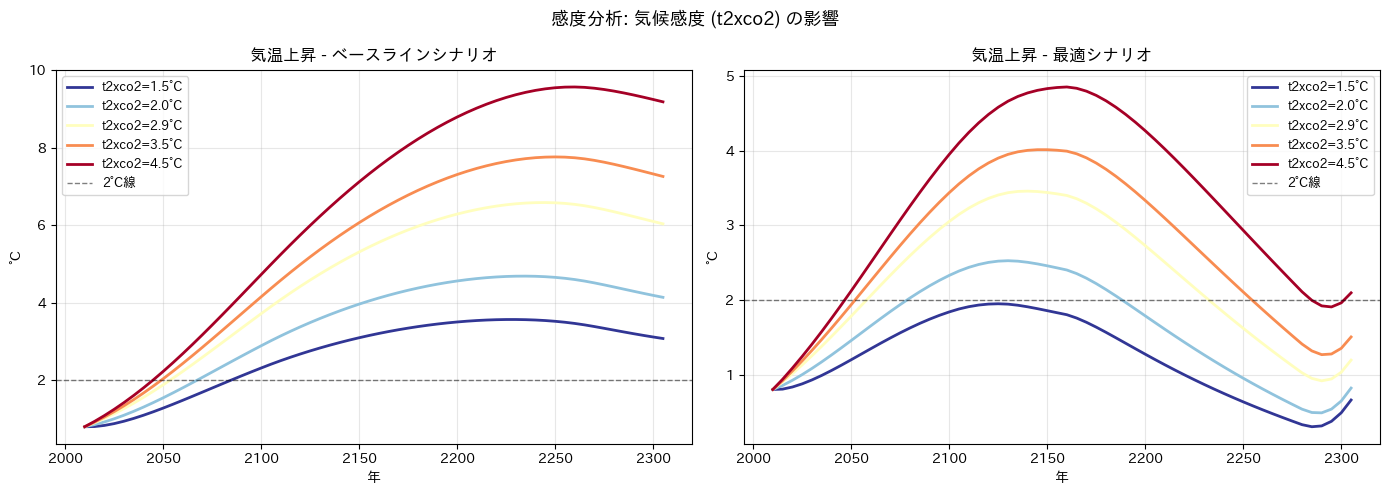

✅ 感度分析完了


In [11]:
# ============================================================
# セル11: 感度分析 - 気候感度 (t2xco2) の影響
# ============================================================
# マニュアル §III.C 「気候感度パラメータの不確実性」
# t2xco2: CO₂が2倍になったときの均衡気温上昇（°C）
#   IPCC推計レンジ: 1.5°C〜4.5°C
#   DICE-2013R採用値: 2.9°C
# ============================================================

print("🔄 感度分析: 気候感度パラメータ (t2xco2) の影響を分析中...")

t2xco2_values = [1.5, 2.0, 2.9, 3.5, 4.5]   # IPCCの推定範囲
colors_sens = plt.cm.RdYlBu_r(np.linspace(0, 1, len(t2xco2_values)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('感度分析: 気候感度 (t2xco2) の影響', fontsize=13, fontweight='bold')

tatm_results = {}

for t2x, col in zip(t2xco2_values, colors_sens):
    # 気候感度を変えてλを再計算
    lam_sens = fco22x / t2x

    # 感度分析用の簡易シミュレーション関数（ローカルで lam を上書き）
    def simulate_sens(t2x_val, miu_path, s_path):
        """気候感度 t2xco2 を変えたシミュレーション"""
        lam_s = fco22x / t2x_val   # 感度パラメータ
        MAT  = np.zeros(T+2); MU = np.zeros(T+2); ML = np.zeros(T+2)
        FORC = np.zeros(T+1); TATM = np.zeros(T+2); TOCEAN = np.zeros(T+2)
        K = np.zeros(T+2)
        MAT[1]=mat0; MU[1]=mu0; ML[1]=ml0
        TATM[1]=tatm0; TOCEAN[1]=tocean0; K[1]=k0
        for t in range(1, T+1):
            YGROSS_s = al[t] * (L[t]/1000)**(1-gama) * K[t]**gama
            FORC[t] = fco22x * np.log(MAT[t]/588)/np.log(2) + forcoth[t-1]
            DAMFRAC_s = a1*TATM[t] + a2*TATM[t]**a3
            ABATE_s = YGROSS_s * cost1[t] * miu_path[t]**expcost2 * partfract[t]**(1-expcost2)
            Y_s = YGROSS_s*(1-DAMFRAC_s) - ABATE_s
            I_s = s_path[t] * Y_s
            EIND_s = sigma[t]*(1-miu_path[t])*YGROSS_s
            E_s = EIND_s + etree[t-1]
            if t < T+1:
                K[t+1]  = max((1-dk)**tstep*K[t]+tstep*I_s, 1.0)
                MAT[t+1]= max(MAT[t]*b11+MU[t]*b21+E_s*tstep/3.666, 10.0)
                MU[t+1] = max(MAT[t]*b12+MU[t]*b22+ML[t]*b32, 100.0)
                ML[t+1] = max(MU[t]*b23+ML[t]*b33, 1000.0)
                TATM[t+1]= min(max(TATM[t]+c1*(FORC[t]-lam_s*TATM[t]-c3*(TATM[t]-TOCEAN[t])),0.),40.)
                TOCEAN[t+1]= min(max(TOCEAN[t]+c4*(TATM[t]-TOCEAN[t]),-1.),20.)
        return TATM

    tatm_s = simulate_sens(t2x, miu_base, s_base)
    tatm_results[t2x] = tatm_s

    axes[0].plot(yr, tatm_s[1:T+1], color=col, linewidth=2,
                 label=f't2xco2={t2x}°C')
    tatm_o = simulate_sens(t2x, miu_opt, s_opt)
    axes[1].plot(yr, tatm_o[1:T+1], color=col, linewidth=2,
                 label=f't2xco2={t2x}°C')

for ax, title in zip(axes, ['ベースラインシナリオ', '最適シナリオ']):
    ax.axhline(2.0, color='black', linewidth=1, linestyle='--', alpha=0.5, label='2°C線')
    ax.set_title(f'気温上昇 - {title}')
    ax.set_xlabel('年')
    ax.set_ylabel('°C')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ 感度分析完了")

In [12]:
# ============================================================
# セル12: 変数一覧と概念解説（初学者向けリファレンス）
# ============================================================

reference = {
    '■ 制御変数（最適化で決定する変数）': {
        'MIU(t)': '排出削減率 [0〜1+]: 0=削減なし, 1=100%削減。1超えはネガティブエミッション',
        'S(t)':   '貯蓄率 [0〜1]: GDP中の投資割合（消費と投資のトレードオフ）',
    },
    '■ 経済変数': {
        'YGROSS(t)': '粗GDP（気候影響前）[兆$]: A(t)・L(t)^(1-γ)・K(t)^γ',
        'YNET(t)':   '被害控除後GDP = YGROSS × (1 - DAMFRAC)',
        'Y(t)':      '純GDP（被害+削減費用控除後） = YNET - ABATECOST',
        'C(t)':      '消費 [兆$/年] = Y - I',
        'I(t)':      '投資 [兆$/年] = S × Y',
        'K(t)':      '資本ストック [兆$]: 永久インベントリ法で更新',
        'CPC(t)':    '一人当たり消費 [千$/年] = 1000 × C / L',
        'RI(t)':     '実質利子率 [年率]',
    },
    '■ 被害・コスト変数': {
        'DAMFRAC(t)':  '気候被害のGDP比 = a1×TATM + a2×TATM^a3',
        'DAMAGES(t)':  '気候被害額 [兆$] = YGROSS × DAMFRAC',
        'ABATECOST(t)':'削減費用 [兆$] = YGROSS × cost1 × MIU^θ₂',
        'CPRICE(t)':   '炭素価格（社会的費用）[$/tCO₂]',
        'MCABATE(t)':  '削減の限界費用 [$/tCO₂]',
    },
    '■ 排出・累積変数': {
        'EIND(t)': '産業CO₂排出量 [GtCO₂/年] = σ(t)×(1-MIU)×YGROSS',
        'E(t)':    '総CO₂排出量 [GtCO₂/年] = EIND + ELand',
        'CCA(t)':  '累積炭素排出量 [GtC]: 化石燃料上限 fosslim=6000GtC 以下',
    },
    '■ 炭素循環変数（3層モデル）': {
        'MAT(t)': '大気中炭素濃度 [GtC from 1750]: 主要な温暖化ドライバー',
        'MU(t)':  '上層海洋+生物圏の炭素濃度 [GtC]: 大気と速やかに交換',
        'ML(t)':  '深海の炭素濃度 [GtC]: 長期的な炭素吸収源',
    },
    '■ 気候変数': {
        'FORC(t)':   '放射強制力 [W/m²]: CO₂増加による熱収支の変化量',
        'TATM(t)':   '大気気温上昇 [°C from 1900]: 主要な政策目標変数',
        'TOCEAN(t)': '深海気温上昇 [°C from 1900]: 熱慣性により遅れて上昇',
    },
    '■ 効用・厚生変数': {
        'PERIODU(t)':    '瞬間効用: CPC^(1-α)/(1-α) - 1 (CRRA型効用関数)',
        'CEMUTOTPER(t)': '加重効用: PERIODU × L(t) × R(t)（人口×割引）',
        'UTILITY':       '社会厚生（目的関数）: tstep×scale1×Σ CEMUTOTPER + scale2',
    },
    '■ 外生パラメータ（時系列）': {
        'L(t)':       '世界人口 [100万人]: ロジスティック成長, 上限10500(=105億人)',
        'al(t)':      '全要素生産性(TFP) A(t): 技術進歩を表す乗数',
        'sigma(t)':   '炭素強度 [kgCO₂/$]: 脱炭素技術進歩により低下',
        'etree(t)':   '土地利用CO₂排出 [GtCO₂/年]: 外生的に低下',
        'forcoth(t)': 'CO₂以外のGHGによる外生的放射強制力 [W/m²]',
        'rr(t)':      '世代間割引因子: 1/(1+ρ)^(5×(t-1))',
    },
}

print("=" * 65)
print(" DICE-2013R モデル 変数・パラメータ リファレンス")
print("=" * 65)
for section, items in reference.items():
    print(f"\n{section}")
    print("-" * 55)
    for var, desc in items.items():
        print(f"  {var:<16}: {desc}")

print("\n" + "=" * 65)
print("\n📚 参考文献:")
print("  Nordhaus, W. (2013). DICE 2013R: Introduction and User's Manual.")
print("  Yale University. https://dicemodel.net")
print("\n  GitHub実装: https://github.com/moptimization/pythondice2013implementation")
print("  (Python/Pyomo版の原実装 → 本ノートブックはSciPy/Python3に移植)")

 DICE-2013R モデル 変数・パラメータ リファレンス

■ 制御変数（最適化で決定する変数）
-------------------------------------------------------
  MIU(t)          : 排出削減率 [0〜1+]: 0=削減なし, 1=100%削減。1超えはネガティブエミッション
  S(t)            : 貯蓄率 [0〜1]: GDP中の投資割合（消費と投資のトレードオフ）

■ 経済変数
-------------------------------------------------------
  YGROSS(t)       : 粗GDP（気候影響前）[兆$]: A(t)・L(t)^(1-γ)・K(t)^γ
  YNET(t)         : 被害控除後GDP = YGROSS × (1 - DAMFRAC)
  Y(t)            : 純GDP（被害+削減費用控除後） = YNET - ABATECOST
  C(t)            : 消費 [兆$/年] = Y - I
  I(t)            : 投資 [兆$/年] = S × Y
  K(t)            : 資本ストック [兆$]: 永久インベントリ法で更新
  CPC(t)          : 一人当たり消費 [千$/年] = 1000 × C / L
  RI(t)           : 実質利子率 [年率]

■ 被害・コスト変数
-------------------------------------------------------
  DAMFRAC(t)      : 気候被害のGDP比 = a1×TATM + a2×TATM^a3
  DAMAGES(t)      : 気候被害額 [兆$] = YGROSS × DAMFRAC
  ABATECOST(t)    : 削減費用 [兆$] = YGROSS × cost1 × MIU^θ₂
  CPRICE(t)       : 炭素価格（社会的費用）[$/tCO₂]
  MCABATE(t)      : 削減の限界費用 [$/tCO₂]

■ 排出・累積変数
------------------